Purpose: regression forecasts with chronological splits; compare persistence baselines, models without IF anomaly flags, and models with IF flags across multiple horizons.

Load engineered data and Isolation Forest flags.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

artifacts = Path('artifacts')
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

fe_path = artifacts / 'feature_engineered.csv'
if not fe_path.exists():
    raise FileNotFoundError('Missing artifacts/feature_engineered.csv - run feature engineering first')

df = pd.read_csv(fe_path, parse_dates=['datetime']).sort_values('datetime').set_index('datetime')

iso_path = artifacts / 'isolation_forest_anomalies.csv'
if iso_path.exists():
    iso = pd.read_csv(iso_path, parse_dates=['timestamp'])
    iso['flag'] = 1
    iso_wide = iso.pivot_table(index='timestamp', columns='stream', values='flag', aggfunc='max')
    iso_wide = iso_wide.add_prefix('anom_iso_').reindex(df.index).fillna(0)
else:
    iso_wide = pd.DataFrame(index=df.index)

candidate_targets = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
targets = [c for c in candidate_targets if c in df.columns]
print('Regression targets:', targets)

HORIZONS = [1, 6, 12, 24]
base_feature_cols = [c for c in df.columns if c not in candidate_targets]
print('Number of base features:', len(base_feature_cols))


Regression targets: ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
Number of base features: 102


Helper for chronological split.

In [2]:
def chronological_split(data, target_cols, test_year=2005, val_ratio=0.15):
    feature_cols_local = [c for c in data.columns if c not in target_cols]
    train_val = data[data.index.year < test_year]
    test = data[data.index.year == test_year]
    n_val = int(len(train_val) * val_ratio)
    train = train_val.iloc[:-n_val] if n_val > 0 else train_val
    val = train_val.iloc[-n_val:] if n_val > 0 else pd.DataFrame()
    return {
        'X_train': train[feature_cols_local],
        'y_train': train[target_cols],
        'X_val': val[feature_cols_local],
        'y_val': val[target_cols] if len(val) else pd.DataFrame(columns=target_cols),
        'X_test': test[feature_cols_local],
        'y_test': test[target_cols],
    }


Train/evaluate per target ? horizon for variants (no IF flags vs with IF flags) plus persistence baselines.

In [3]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}

results = []
pred_curves = {}

for tgt in targets:
    print("\n==============================")
    print(f"Target: {tgt}")
    print("==============================")
    for h in HORIZONS:
        label_col = f"{tgt}_t_plus_{h}"
        df_h = df.copy()
        df_h[label_col] = df_h[tgt].shift(-h)
        df_h = df_h.dropna(subset=[label_col])

        variants = {
            'No IF flags': df_h[base_feature_cols + [label_col]],
            'With IF flags': df_h.join(iso_wide)[base_feature_cols + list(iso_wide.columns) + [label_col]] if not iso_wide.empty else df_h[base_feature_cols + [label_col]],
        }

        for variant_name, df_variant in variants.items():
            df_variant = df_variant.dropna(axis=1, how='all')
            used_cols = [c for c in df_variant.columns if c != label_col] + [label_col]
            df_variant = df_variant[used_cols].sort_index()

            splits = chronological_split(df_variant, [label_col])
            X_train, y_train = splits['X_train'], splits['y_train'][label_col]
            X_val, y_val = splits['X_val'], splits['y_val'][label_col]
            X_test, y_test = splits['X_test'], splits['y_test'][label_col]

            print(f"\n--- Horizon {h}h ({variant_name}) ---")
            print('Train size:', X_train.shape, 'Val size:', X_val.shape, 'Test size:', X_test.shape)

            baseline_pred_test = df.loc[y_test.index, tgt]
            baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_test))
            baseline_mae = mean_absolute_error(y_test, baseline_pred_test)

            for model_name, model in models.items():
                pipe = Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                    ('model', model),
                ])

                pipe.fit(X_train, y_train)

                y_pred_train = pipe.predict(X_train)
                y_pred_val = pipe.predict(X_val) if len(X_val) else np.array([])
                y_pred_test = pipe.predict(X_test)

                rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
                mae_train = mean_absolute_error(y_train, y_pred_train)
                r2_train = r2_score(y_train, y_pred_train)

                if len(X_val):
                    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
                    mae_val = mean_absolute_error(y_val, y_pred_val)
                    r2_val = r2_score(y_val, y_pred_val)
                else:
                    rmse_val = np.nan
                    mae_val = np.nan
                    r2_val = np.nan

                rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
                mae_test = mean_absolute_error(y_test, y_pred_test)
                r2_test = r2_score(y_test, y_pred_test)

                results.append({
                    'target': tgt,
                    'horizon_h': h,
                    'variant': variant_name,
                    'model': model_name,
                    'rmse_train': rmse_train,
                    'mae_train': mae_train,
                    'r2_train': r2_train,
                    'rmse_val': rmse_val,
                    'mae_val': mae_val,
                    'r2_val': r2_val,
                    'rmse_test': rmse_test,
                    'mae_test': mae_test,
                    'r2_test': r2_test,
                    'baseline_rmse_test': baseline_rmse,
                    'baseline_mae_test': baseline_mae,
                })

                print(f"{variant_name} | {model_name}: test RMSE={rmse_test:.3f}, MAE={mae_test:.3f}, R2={r2_test:.3f} (baseline RMSE={baseline_rmse:.3f})")

                if model_name == 'GradientBoosting' and (tgt, h) not in pred_curves and variant_name == 'No IF flags':
                    pred_curves[(tgt, h)] = {
                        'time': X_test.index,
                        'y_true': y_test.values,
                        'y_pred': y_pred_test,
                    }

results_df = pd.DataFrame(results).sort_values(['target', 'horizon_h', 'variant', 'rmse_test']).reset_index(drop=True)
results_df = pd.DataFrame(results).sort_values(['target', 'horizon_h', 'variant', 'rmse_test']).reset_index(drop=True)
print("\n================ Full Regression Results ================")
display(results_df.head())

best_df = results_df.loc[results_df.groupby(['target', 'horizon_h', 'variant'])['rmse_test'].idxmin()].reset_index(drop=True)
best_df = results_df.loc[results_df.groupby(['target', 'horizon_h', 'variant'])['rmse_test'].idxmin()].reset_index(drop=True)
print("\n================ Best Model per Target x Horizon x Variant ================")
display(best_df)

pivot_rmse = best_df.pivot_table(index=['target', 'variant'], columns='horizon_h', values='rmse_test')
pivot_rmse = best_df.pivot_table(index=['target', 'variant'], columns='horizon_h', values='rmse_test')
print("\n================ Pivot Table (Test RMSE) ================")
display(pivot_rmse)

results_df.to_csv(artifacts / 'regression_metrics.csv', index=False)


Target: CO(GT)

--- Horizon 1h (No IF flags) ---
Train size: (6024, 102) Val size: (1062, 102) Test size: (2246, 102)
No IF flags | LinearRegression: test RMSE=0.501, MAE=0.373, R2=0.723 (baseline RMSE=0.546)
No IF flags | RandomForest: test RMSE=0.577, MAE=0.420, R2=0.632 (baseline RMSE=0.546)
No IF flags | GradientBoosting: test RMSE=0.601, MAE=0.432, R2=0.601 (baseline RMSE=0.546)

--- Horizon 1h (With IF flags) ---
Train size: (6024, 112) Val size: (1062, 112) Test size: (2246, 112)
With IF flags | LinearRegression: test RMSE=0.513, MAE=0.388, R2=0.709 (baseline RMSE=0.546)
With IF flags | RandomForest: test RMSE=0.579, MAE=0.421, R2=0.630 (baseline RMSE=0.546)
With IF flags | GradientBoosting: test RMSE=0.579, MAE=0.409, R2=0.630 (baseline RMSE=0.546)

--- Horizon 6h (No IF flags) ---
Train size: (6024, 102) Val size: (1062, 102) Test size: (2241, 102)
No IF flags | LinearRegression: test RMSE=0.859, MAE=0.675, R2=0.187 (baseline RMSE=1.239)
No IF flags | RandomForest: test RMSE=

,target,horizon_h,variant,model,rmse_train,mae_train,r2_train,rmse_val,mae_val,r2_val,rmse_test,mae_test,r2_test,baseline_rmse_test,baseline_mae_test
0,C6H6(GT),1,No IF flags,LinearRegression,0.376814,0.248880,0.831495,0.448100,0.314837,0.870302,0.404421,0.280649,0.855959,0.426521,0.238507
1,C6H6(GT),1,No IF flags,RandomForest,0.130863,0.079334,0.979677,0.806455,0.439939,0.579909,0.603747,0.343436,0.678984,0.426521,0.238507
2,C6H6(GT),1,No IF flags,GradientBoosting,0.294771,0.194750,0.896883,0.834829,0.449682,0.549828,0.633993,0.400049,0.646015,0.426521,0.238507
3,C6H6(GT),1,With IF flags,LinearRegression,0.375945,0.248925,0.832271,0.447504,0.315604,0.870647,0.408023,0.284177,0.853382,0.426521,0.238507
4,C6H6(GT),1,With IF flags,RandomForest,0.130889,0.079295,0.979669,0.808450,0.439972,0.577828,0.596982,0.340997,0.686137,0.426521,0.238507



================ Best Model per Target x Horizon x Variant ================


,target,horizon_h,variant,model,rmse_train,mae_train,r2_train,rmse_val,mae_val,r2_val,rmse_test,mae_test,r2_test,baseline_rmse_test,baseline_mae_test
0,C6H6(GT),1,No IF flags,LinearRegression,0.376814,0.248880,0.831495,0.448100,0.314837,0.870302,0.404421,0.280649,0.855959,0.426521,0.238507
1,C6H6(GT),1,With IF flags,LinearRegression,0.375945,0.248925,0.832271,0.447504,0.315604,0.870647,0.408023,0.284177,0.853382,0.426521,0.238507
2,C6H6(GT),6,No IF flags,LinearRegression,0.614419,0.435439,0.551995,0.910520,0.661029,0.463747,0.749345,0.557616,0.506435,0.963992,0.665531
3,C6H6(GT),6,With IF flags,LinearRegression,0.611363,0.433678,0.556440,0.940282,0.672975,0.428117,0.739176,0.544511,0.519740,0.963992,0.665531
4,C6H6(GT),12,No IF flags,LinearRegression,0.670295,0.458872,0.466638,1.059531,0.741343,0.274141,0.855982,0.609624,0.357075,1.063391,0.744347
5,C6H6(GT),12,With IF flags,LinearRegression,0.666825,0.455214,0.472145,1.079577,0.759000,0.246415,0.857461,0.592463,0.354850,1.063391,0.744347
6,C6H6(GT),24,No IF flags,LinearRegression,0.725367,0.482788,0.376027,1.119748,0.792749,0.188095,0.983042,0.683977,0.156144,0.988226,0.562284
7,C6H6(GT),24,With IF flags,LinearRegression,0.722906,0.479542,0.380253,1.148068,0.815914,0.146508,0.981158,0.660863,0.159377,0.988226,0.562284
8,CO(GT),1,No IF flags,LinearRegression,0.410772,0.291561,0.808898,0.587740,0.430030,0.791651,0.501445,0.373293,0.722584,0.546150,0.351874
9,CO(GT),1,With IF flags,LinearRegression,0.408834,0.290808,0.810697,0.593797,0.435410,0.787335,0.513150,0.388377,0.709482,0.546150,0.351874



================ Pivot Table (Test RMSE) ================


horizon_h                     1         6         12        24
target   variant                                              
C6H6(GT) No IF flags    0.404421  0.749345  0.855982  0.983042
         With IF flags  0.408023  0.739176  0.857461  0.981158
CO(GT)   No IF flags    0.501445  0.834027  0.783496  0.851557
         With IF flags  0.513150  0.829021  0.787060  0.849014
NMHC(GT) No IF flags    0.458149  0.695917  0.722028  0.695096
         With IF flags  0.488983  0.671183  0.730597  0.683240
NO2(GT)  No IF flags    0.624617  0.888489  0.910741  0.958870
         With IF flags  0.616441  0.887997  0.914190  0.959881
NOx(GT)  No IF flags    0.580023  0.873786  0.955709  1.003015
         With IF flags  0.569752  0.883552  0.956598  1.003642

Example plots: true vs predicted and residual histogram for a sample target/horizon (no IF flags).

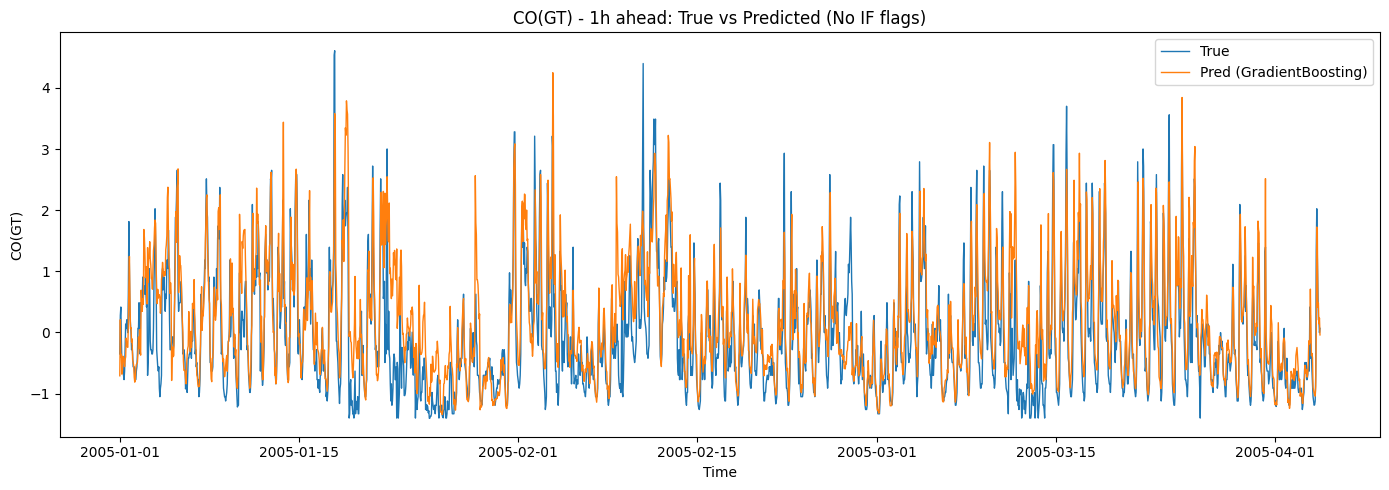

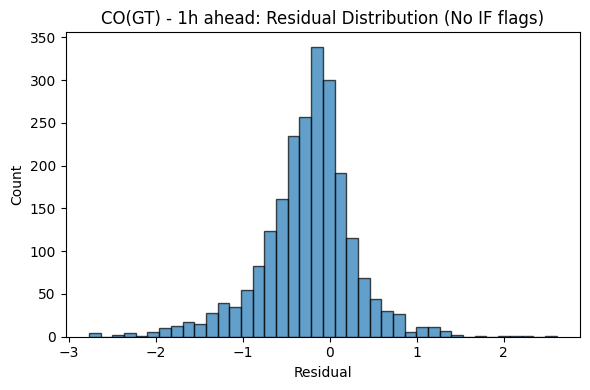

In [4]:
if pred_curves:
    example_key = list(pred_curves.keys())[0]
    example_target, example_horizon = example_key
    pc = pred_curves[example_key]
    time_axis, y_true, y_pred = pc['time'], pc['y_true'], pc['y_pred']

    plt.figure(figsize=(14, 5))
    plt.plot(time_axis, y_true, label='True', linewidth=1)
    plt.plot(time_axis, y_pred, label='Pred (GradientBoosting)', linewidth=1)
    plt.title(f"{example_target} - {example_horizon}h ahead: True vs Predicted (No IF flags)")
    plt.xlabel('Time')
    plt.ylabel(example_target)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{example_target.replace('(GT)','').lower()}_{example_horizon}h_true_vs_pred.png", dpi=150)
    plt.show()

    residuals = y_true - y_pred
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=40, edgecolor='k', alpha=0.7)
    plt.title(f"{example_target} - {example_horizon}h ahead: Residual Distribution (No IF flags)")
    plt.xlabel('Residual')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(fig_dir / f"{example_target.replace('(GT)','').lower()}_{example_horizon}h_residuals.png", dpi=150)
    plt.show()
else:
    print('No prediction curves stored.')


Feature importance (RandomForest) for the same example horizon (no IF flags).

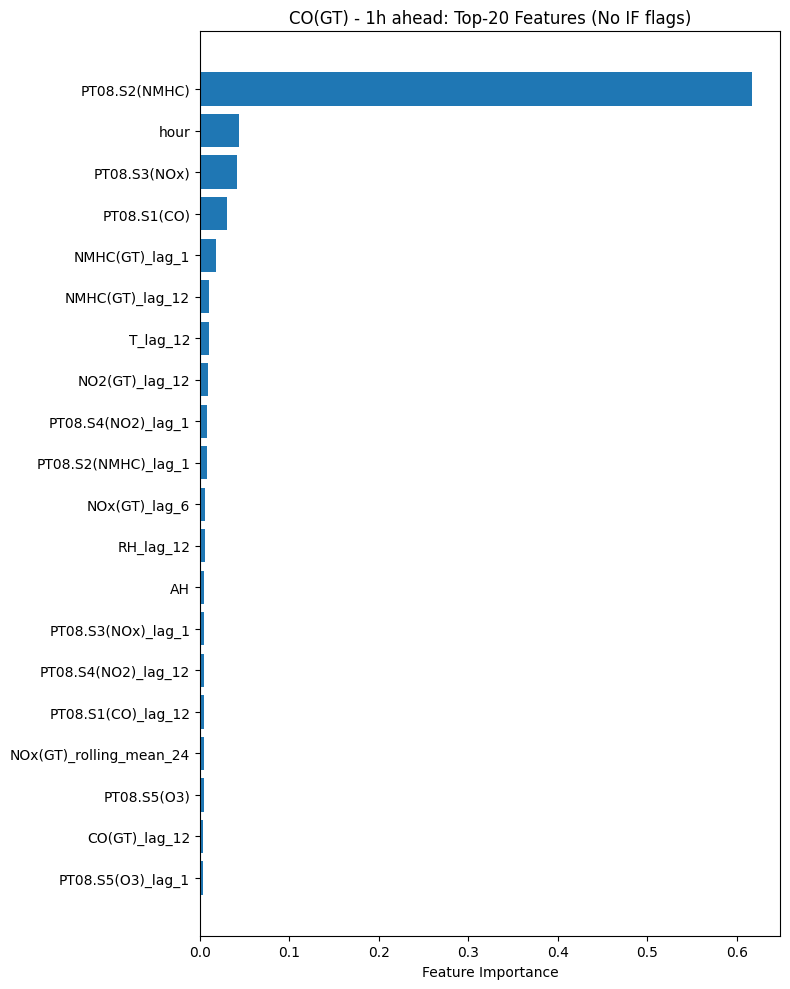

In [5]:
if pred_curves:
    tgt, h = list(pred_curves.keys())[0]
    label_col = f"{tgt}_t_plus_{h}"
    df_imp = df.copy()
    df_imp[label_col] = df_imp[tgt].shift(-h)
    df_imp = df_imp.dropna(subset=[label_col])
    used_feature_cols = [c for c in base_feature_cols if c in df_imp.columns]
    df_imp = df_imp[used_feature_cols + [label_col]].sort_index()
    splits_imp = chronological_split(df_imp, [label_col])
    X_train_imp = splits_imp['X_train']
    y_train_imp = splits_imp['y_train'][label_col]

    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    imp_imputer = SimpleImputer(strategy='median')
    X_train_imp_imputed = imp_imputer.fit_transform(X_train_imp)
    rf.fit(X_train_imp_imputed, y_train_imp)

    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_k = min(20, len(used_feature_cols))

    plt.figure(figsize=(8, 0.4 * top_k + 2))
    plt.barh(range(top_k), importances[indices[:top_k]][::-1])
    plt.yticks(range(top_k), [used_feature_cols[i] for i in indices[:top_k]][::-1])
    plt.xlabel('Feature Importance')
    plt.title(f"{tgt} - {h}h ahead: Top-{top_k} Features (No IF flags)")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tgt.replace('(GT)','').lower()}_{h}h_feature_importance.png", dpi=150)
    plt.show()
else:
    print('No prediction curves stored for feature importance.')
